Jalur Python: C:\anaconda3\envs\metodepotensial\python.exe
✅ SEMUA LIBRARY TERDETEKSI: xarray, harmonica, pyproj, verde siap digunakan.
Data berhasil dimuat: 90000 baris.


C:\anaconda3\envs\metodepotensial\lib\site-packages\verde\blockreduce.py:179: FutureWarning: The provided callable <function median at 0x000001877A088E50> is currently using DataFrameGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  blocked = pd.DataFrame(columns).groupby("block").aggregate(reduction)
C:\anaconda3\envs\metodepotensial\lib\site-packages\verde\blockreduce.py:236: FutureWarning: The provided callable <function median at 0x000001877A088E50> is currently using DataFrameGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  grouped = table.groupby("block").aggregate(self.reduction)


✅ Gridding Berhasil!


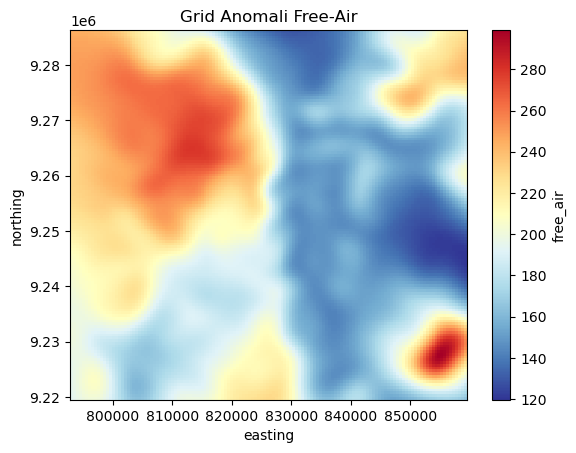

In [2]:
import sys
import os

# Menampilkan jalur Python yang sedang digunakan oleh VS Code saat ini
print(f"Jalur Python: {sys.executable}")

try:
    import xarray as xr
    import harmonica as hm
    import pyproj
    import verde as vd
    print("✅ SEMUA LIBRARY TERDETEKSI: xarray, harmonica, pyproj, verde siap digunakan.")
except ImportError as e:
    print(f"❌ ERROR: {e}")
    print("Sedang mencoba sinkronisasi paksa...")
    # Perintah di bawah ini akan menginstal langsung ke jalur yang digunakan Notebook
    !{sys.executable} -m pip install xarray harmonica pyproj verde contextily

import pandas as pd
import numpy as np        # Wajib dijalankan
import verde as vd
import pyproj
import xarray as xr
import matplotlib.pyplot as plt

# 1. Load data
try:
    file_csv = "D:/semester_6/Metode_Potensial/Metode-Potensial/data/proses/tampomas_dg_potong.csv"
    df = pd.read_csv(file_csv)
    print(f"Data berhasil dimuat: {len(df)} baris.")
except FileNotFoundError:
    print("Error: File CSV tidak ditemukan. Cek folder data/proses/")

# 2. Transformasi UTM
proj_utm = pyproj.Proj(proj="utm", zone=48, south=True, ellps="WGS84")
df['easting'], df['northing'] = proj_utm(df.longitude.values, df.latitude.values)

# 3. Gridding (Gunakan spacing agak besar dulu, misal 500m, agar TIDAK LOOP)
coords = (df.easting, df.northing)
reducer = vd.BlockReduce(np.median, spacing=500) 
c_red, d_red = reducer.filter(coords, df.gravity_dist)

# 4. Fit Spline (Gunakan damping agar proses matematika lebih ringan bagi laptop)
spline = vd.Spline(damping=1e-4).fit(c_red, d_red)

# 5. Generate Grid
grid_fa = spline.grid(spacing=500, data_names="free_air")

# 6. Simpan Hasil
grid_fa.to_netcdf("D:/semester_6/Metode_Potensial/Metode-Potensial/data/proses/grid_tampomas_fa.nc")
print("✅ Gridding Berhasil!")

# 7. Plotting Sederhana
grid_fa.free_air.plot(cmap="RdYlBu_r")
plt.title("Grid Anomali Free-Air")
plt.show()